<a href="https://colab.research.google.com/github/varun0852/for-study/blob/master/Evaluation_metrics%E2%80%8B_%26_Decision_Tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np
from sklearn.metrics import accuracy_score , classification_report , confusion_matrix , roc_auc_score
from sklearn.tree import DecisionTreeClassifier , plot_tree
from sklearn.model_selection import train_test_split
from sklearn import preprocessing
import matplotlib.pyplot as plt
import collections

In [ ]:
# from google.colab import files
# uploaded = files.upload()

In [ ]:
df = pd.read_csv("Bank Customer Churn Prediction.csv")
df

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,15606229,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,15569892,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,15584532,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,15682355,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


# **Decision Tree**
in decision tree we go for label_encoding



whenever there is classification we go with Decision Tree

In [ ]:
x = df.drop(columns=["churn" , "customer_id"])
y = df["churn"]

In [ ]:
label_encoder = preprocessing.LabelEncoder()
x["country"] = label_encoder.fit_transform(x["country"])
x["gender"] = label_encoder.fit_transform(x["gender"])
x

,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary
0,619,0,0,42,2,0.00,1,1,1,101348.88
1,608,2,0,41,1,83807.86,1,0,1,112542.58
2,502,0,0,42,8,159660.80,3,1,0,113931.57
3,699,0,0,39,1,0.00,2,0,0,93826.63
4,850,2,0,43,2,125510.82,1,1,1,79084.10
...,...,...,...,...,...,...,...,...,...,...
9995,771,0,1,39,5,0.00,2,1,0,96270.64
9996,516,0,1,35,10,57369.61,1,1,1,101699.77
9997,709,0,0,36,7,0.00,1,0,1,42085.58
9998,772,1,1,42,3,75075.31,2,1,0,92888.52


### Spliting The Data

In [ ]:
x_train , x_test , y_train , y_test = train_test_split(x , y , test_size=0.2 , random_state=423)

### Deciding The Model

In [ ]:
regr = DecisionTreeClassifier()
regr.fit(x_train , y_train)

DecisionTreeClassifier()

### Training The Train Data


In [ ]:
y_train_pred = regr.predict(x_train)
training_accuracy = accuracy_score(y_train , y_train_pred)

### Training The Test Data

In [ ]:
y_test_pred = regr.predict(x_test)
testing_accuracy = accuracy_score(y_test , y_test_pred)

### Printing The Accuracy

In [ ]:
print("Training_Accuracy:" , training_accuracy)
print("Testing_Accuracy:" , testing_accuracy)

Training_Accuracy: 1.0
Testing_Accuracy: 0.787


In [ ]:
confusion_matrix(y_test , y_test_pred)

array([[1376,  215],
       [ 211,  198]])

### Printing Confusion Metrics

In [ ]:
print(classification_report(y_test , y_test_pred))

              precision    recall  f1-score   support

           0       0.87      0.86      0.87      1591
           1       0.48      0.48      0.48       409

    accuracy                           0.79      2000
   macro avg       0.67      0.67      0.67      2000
weighted avg       0.79      0.79      0.79      2000



In [ ]:
roc_auc_score(y_test , y_test_pred)

np.float64(0.6744862221634838)

In [ ]:
regr.feature_importances_

array([0.14027992, 0.03251126, 0.01923225, 0.23448782, 0.07648366,
       0.14672659, 0.11880743, 0.01840899, 0.05573105, 0.15733103])

In [ ]:
features = {}
for i,j in zip(x.columns , regr.feature_importances_):
  features[i] = j

features

{'credit_score': np.float64(0.14027991933977077),
 'country': np.float64(0.03251125618815148),
 'gender': np.float64(0.01923225329452619),
 'age': np.float64(0.23448782252045997),
 'tenure': np.float64(0.07648366066703777),
 'balance': np.float64(0.1467265892739218),
 'products_number': np.float64(0.11880742648885788),
 'credit_card': np.float64(0.018408990774459722),
 'active_member': np.float64(0.05573105369901786),
 'estimated_salary': np.float64(0.15733102775379662)}

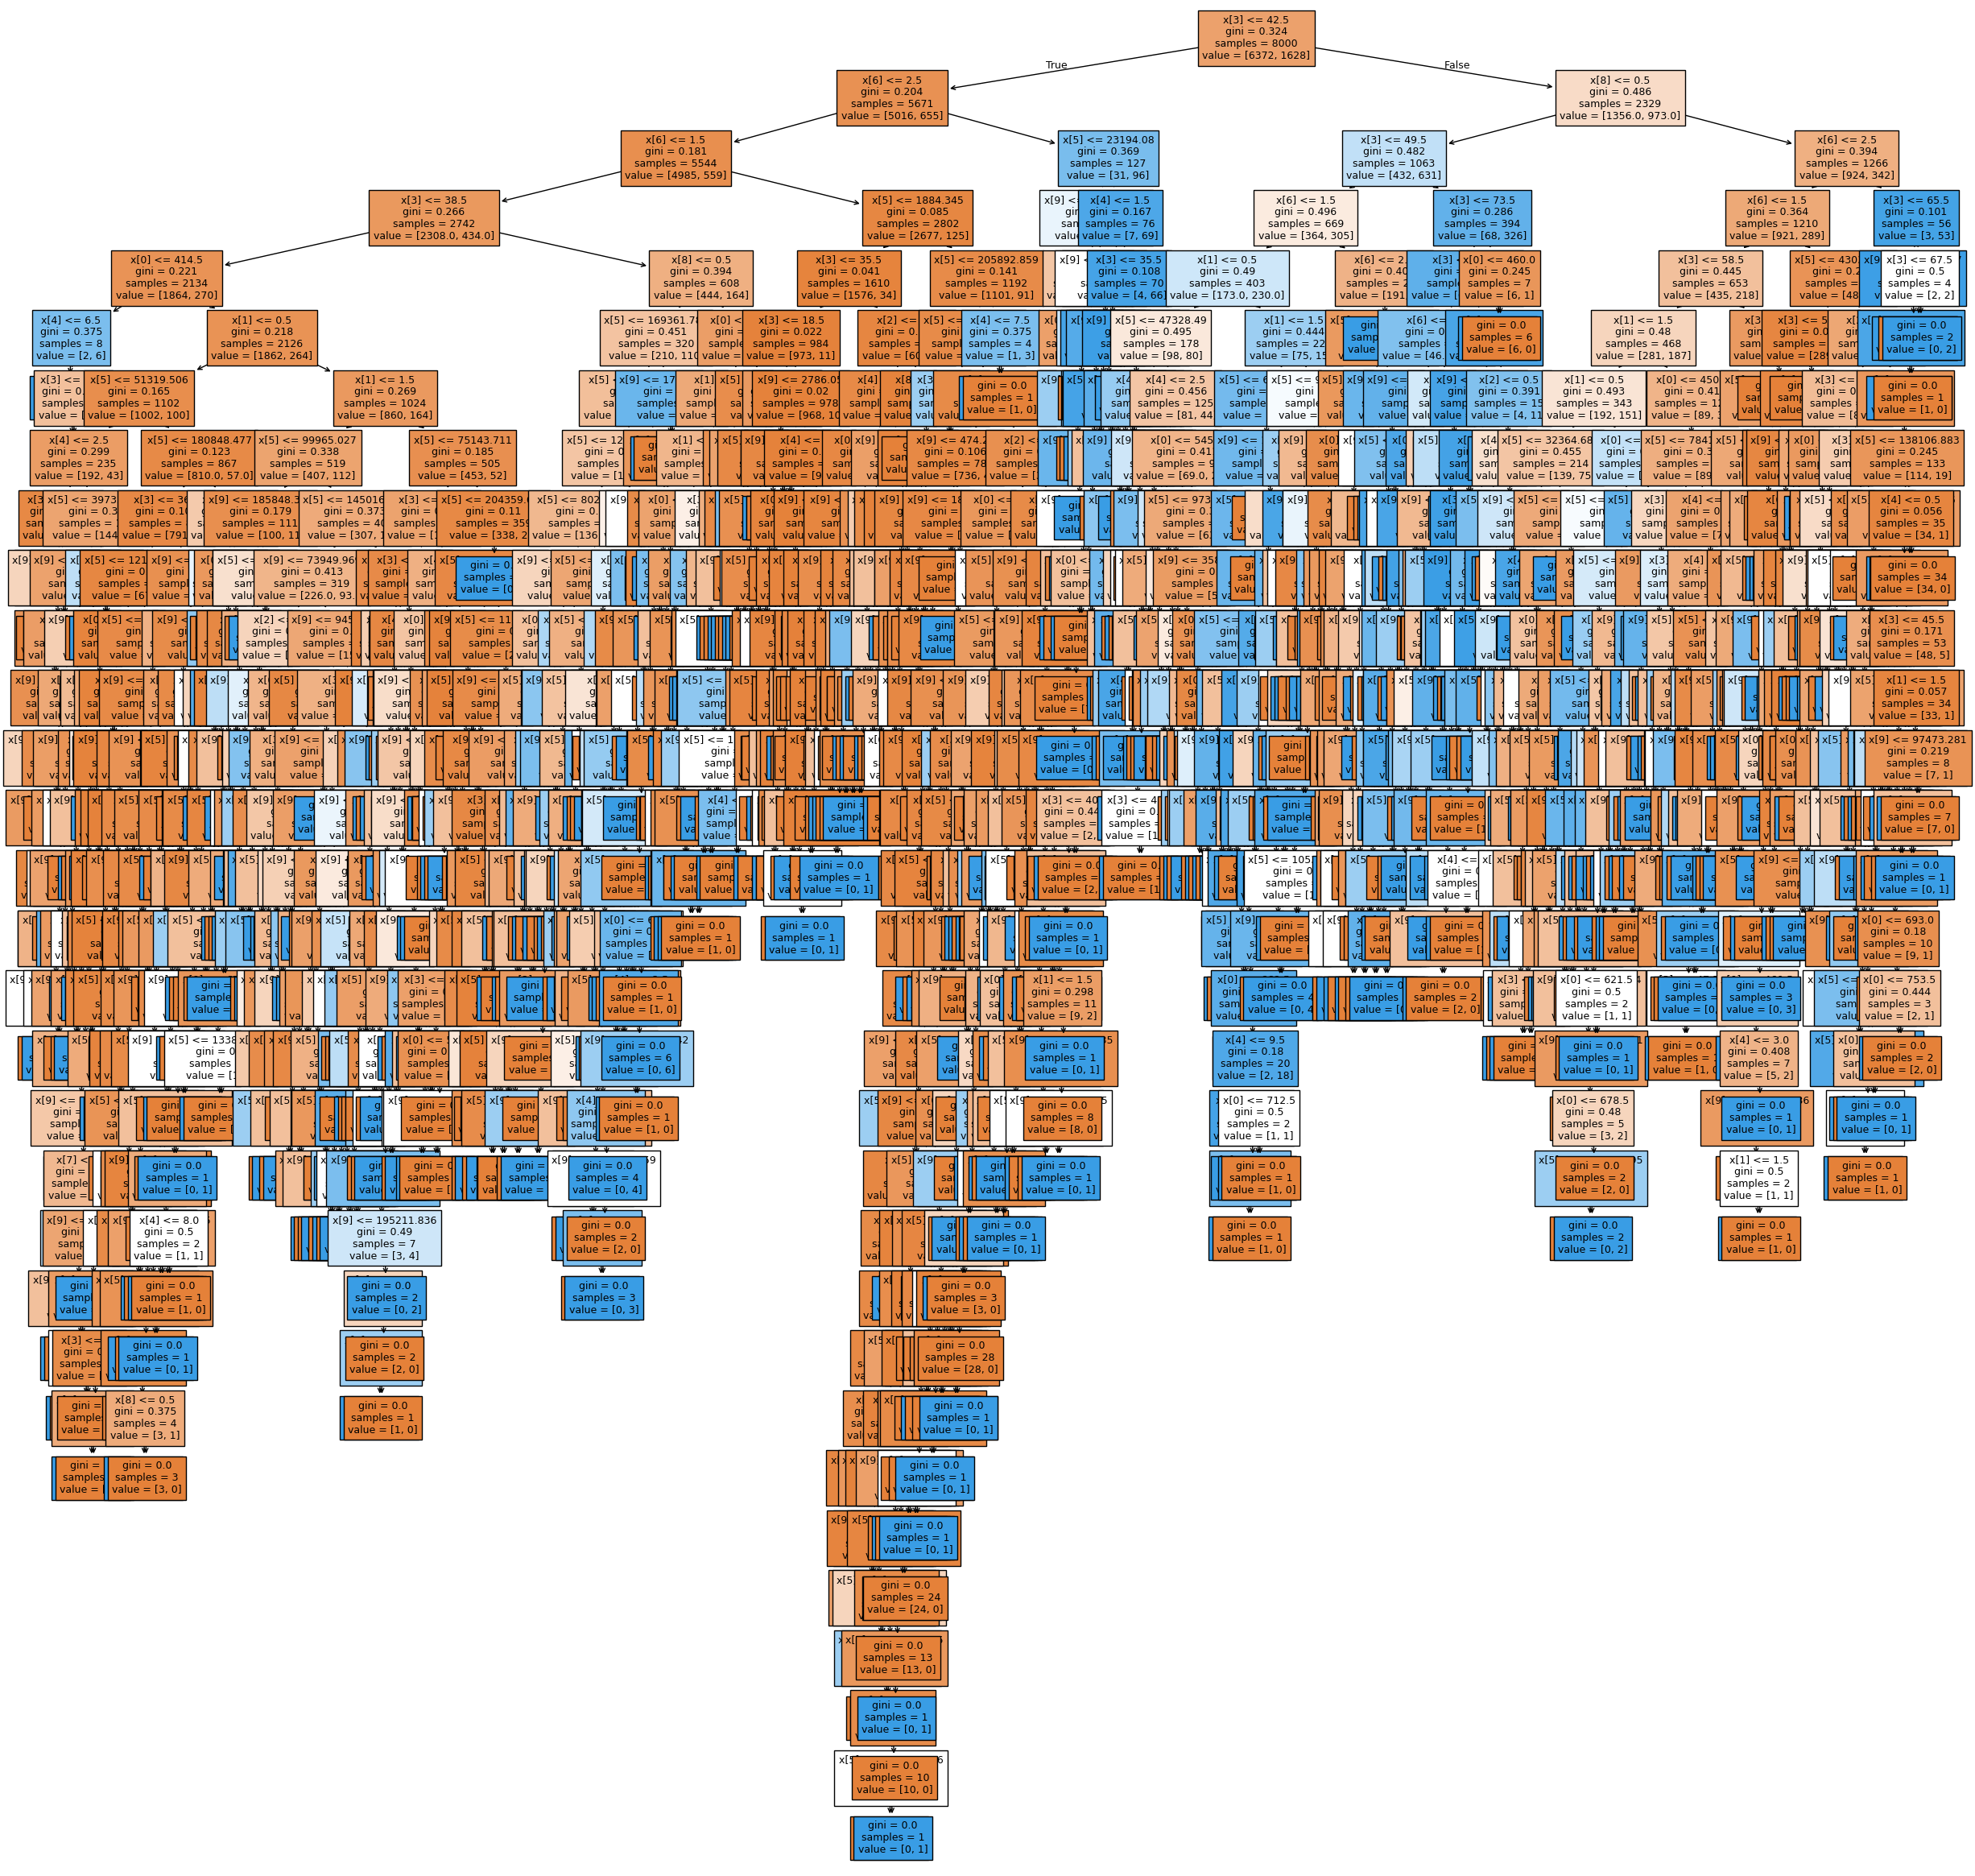

In [ ]:
plt.figure(figsize=(30 , 30))
plot_tree(regr , filled = True , fontsize = 9)
plt.show()

In [ ]:
# use shift+tab To check what needed inside any model
model = DecisionTreeClassifier(max_depth = 10, min_samples_leaf = 100 , min_samples_split = 200 , max_leaf_nodes = 35)
model.fit(x_train , y_train)

# TRAINING ACCURACY
ytrain_pred = model.predict(x_train)
y_training_accuracy = accuracy_score(y_train , ytrain_pred)



# TESTING ACCURACY
ytest_pred = model.predict(x_test)
y_testing_accuracy = accuracy_score(y_test , ytest_pred)


print("y_training_accuracy: " ,  y_training_accuracy)
print("y_testing_accuracy: " , y_testing_accuracy)

# There is no overfitting in this model

y_training_accuracy:  0.848875
y_testing_accuracy:  0.842


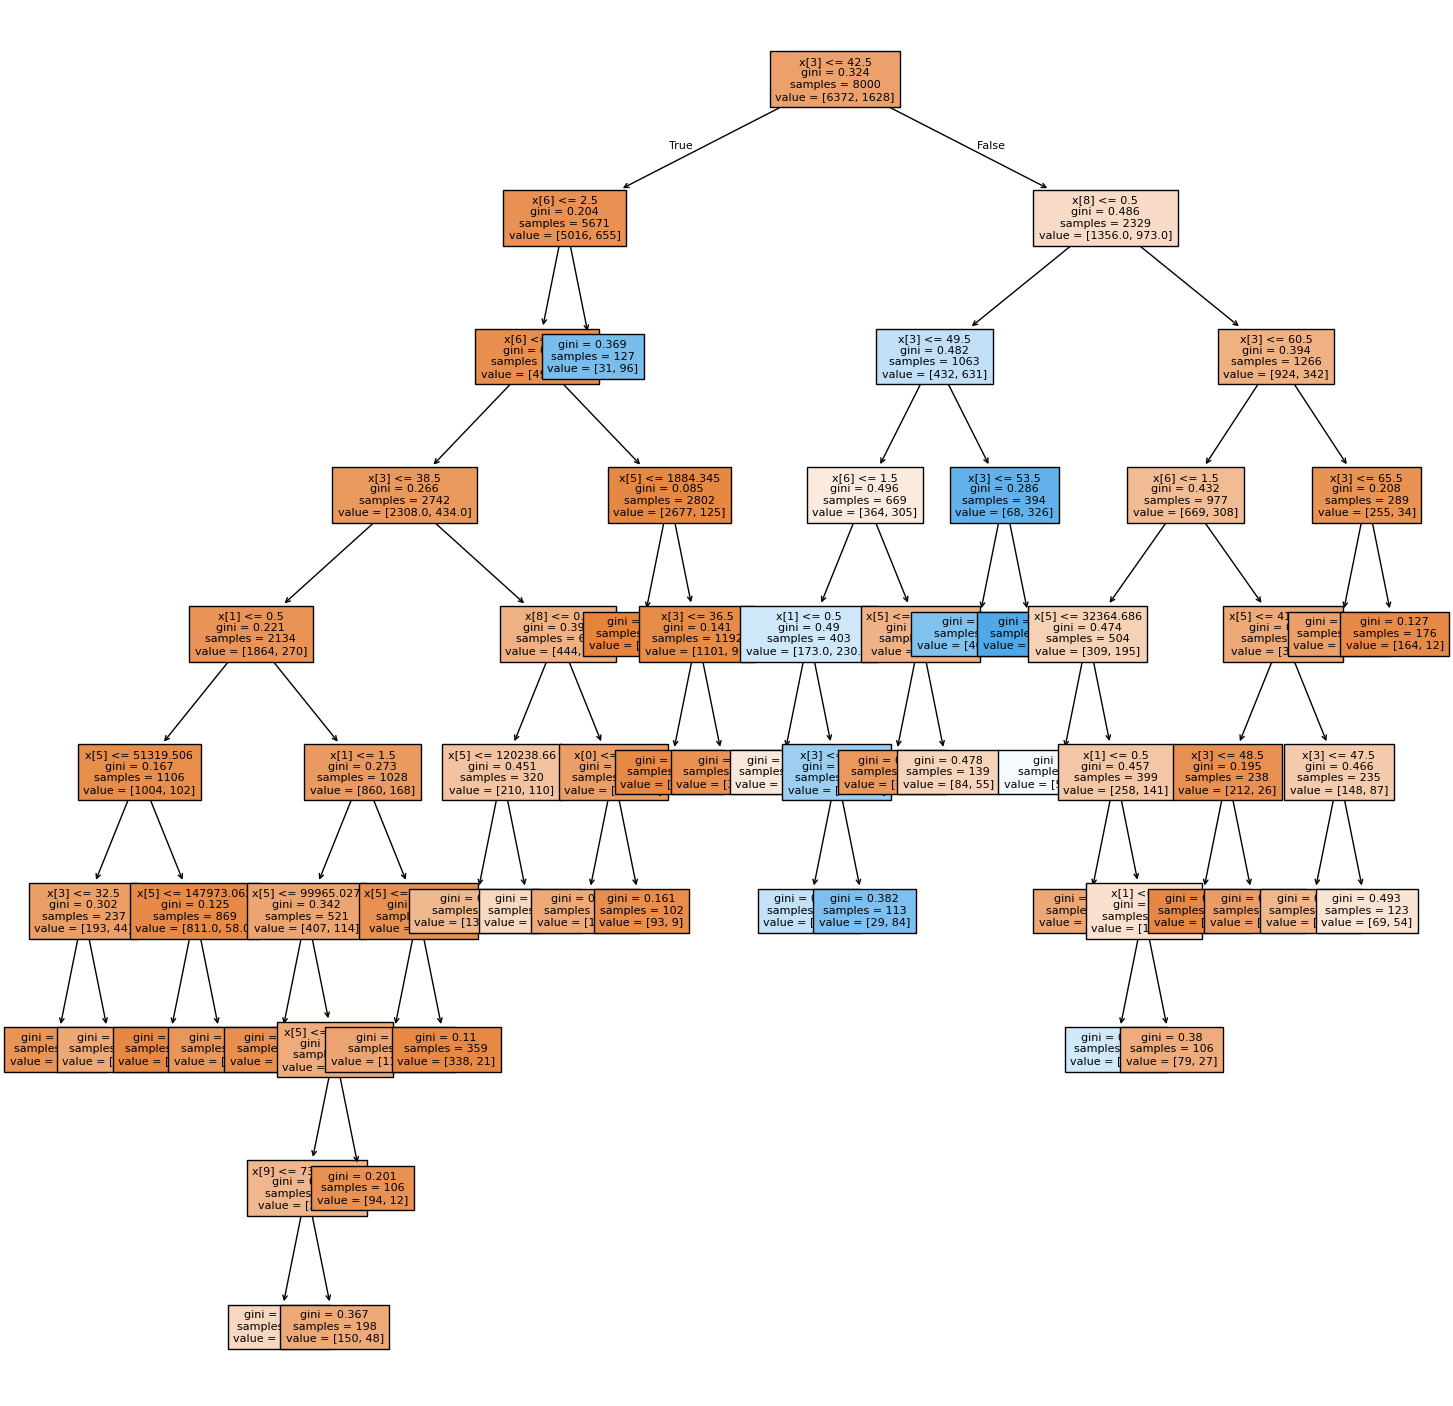

In [ ]:
plt.figure(figsize = (18,18))
plot_tree(model , filled = True , fontsize = 8)
plt.show()